---
# 1. Carregamento do dataset + Tratamento inicial

In [1]:
# ================================
# 1. Upload do arquivo no Colab
# ================================
from google.colab import files
uploaded = files.upload()

# O Colab salva o arquivo no diretório atual.
# Pegamos automaticamente o nome do arquivo enviado:
import pandas as pd

nome_arquivo = list(uploaded.keys())[0]
print("Arquivo carregado:", nome_arquivo)

# ================================
# 2. Carregar dataset
# ================================
df = pd.read_csv(nome_arquivo)

# ================================
# 3. Renomear colunas para o padrão do sistema
# ================================
df = df.rename(columns={
    "job_title": "cargo",
    "experience_level": "nivel_experiencia",
    "employment_type": "tipo_contrato",
    "work_models": "modalidade",
    "salary_in_usd": "salario_usd",
    "employee_residence": "pais_residencia",
    "company_location": "pais_empresa",
    "company_size": "porte_empresa",
    "work_year": "ano"
})

# ================================
# 4. Limpeza básica
# ================================
df["cargo"] = df["cargo"].astype(str).str.strip()
df["modalidade"] = df["modalidade"].astype(str).str.strip()
df["nivel_experiencia"] = df["nivel_experiencia"].astype(str).str.strip()

# ================================
# 5. Visualizar primeiras linhas
# ================================
df.head()

Saving data_science_salaries.csv to data_science_salaries.csv
Arquivo carregado: data_science_salaries.csv


,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


---
# 2. Funções do Sistema (v3 – Pandas)

In [2]:
import os

# Criar a pasta se não existir
os.makedirs("sistema", exist_ok=True)

# Conteúdo do arquivo funcoes.py
conteudo = """
import pandas as pd

def filtrar_por_cargo(df, cargo):
    return df[df["cargo"].str.contains(cargo, case=False, na=False)]

def salario_medio_por_nivel(df):
    return df.groupby("nivel_experiencia")["salario_usd"].mean().sort_values()

def salario_medio_por_modalidade(df):
    return df.groupby("modalidade")["salario_usd"].mean().sort_values()

def salario_medio_por_pais(df):
    return df.groupby("pais_residencia")["salario_usd"].mean().sort_values(ascending=False)

def vagas_por_cargo(df):
    return df["cargo"].value_counts()

def salario_medio_por_ano(df):
    return df.groupby("ano")["salario_usd"].mean()

def modalidade_por_ano(df):
    return df.groupby(["ano", "modalidade"]).size().unstack(fill_value=0)
"""

# Criar o arquivo
with open("sistema/funcoes.py", "w") as f:
    f.write(conteudo)

print("Arquivo sistema/funcoes.py criado com sucesso!")

Arquivo sistema/funcoes.py criado com sucesso!


---
# 3. Pergunta de Negócio 6 — Porte da empresa e salário



**Pergunta:** Empresas grandes (L), médias (M) ou pequenas (S) pagam mais? A diferença é maior em algum nível de experiência específico?

### 🔹 Análise do salário médio por porte da empresa:





<Axes: title={'center': 'Salário médio por porte da empresa'}, xlabel='porte_empresa'>

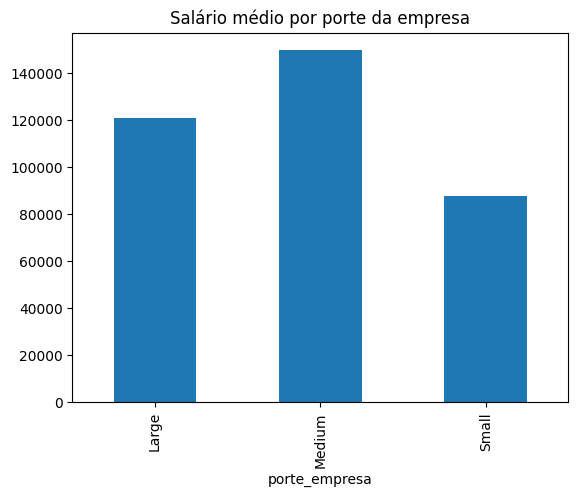

In [3]:

# ================================
# 1. Apresentar o gráfico comparativo
# ================================

df.groupby("porte_empresa")["salario_usd"].mean().plot(
    kind="bar",
    title="Salário médio por porte da empresa"
)

### 🔹 Análise do salário médio por nível de experiência:

<Axes: title={'center': 'Salário por porte da empresa e nível'}, xlabel='porte_empresa'>

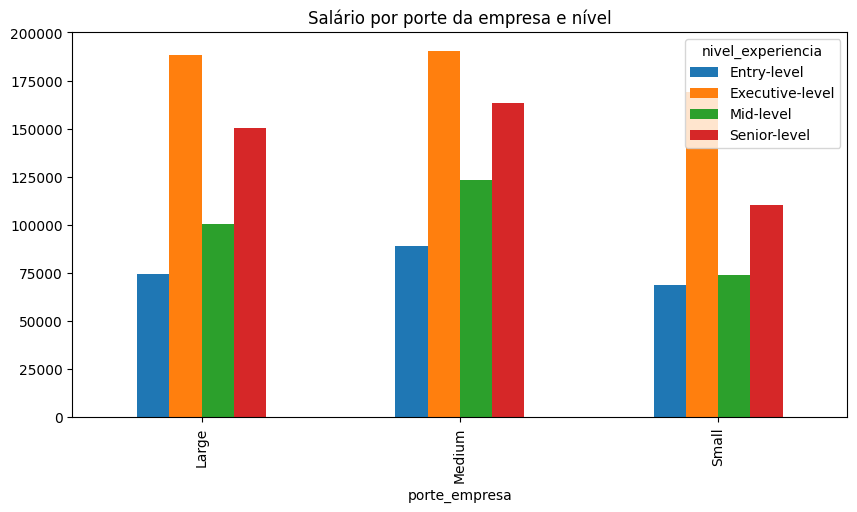

In [4]:

# ================================
# 1. Apresentar o gráfico comparativo
# ================================

df.groupby(["porte_empresa", "nivel_experiencia"])["salario_usd"].mean().unstack().plot(
    kind="bar",
    figsize=(10,5),
    title="Salário por porte da empresa e nível"
)

➡️ **Resposta:** Empresas médias pagam mais em todos os níveis, mas a diferença é mais acentuada no nível MI.